In [6]:
!pip install transformers
!pip install segmentation-models-pytorch
!pip install roboflow
!pip install opencv-python
!pip install albumentations

In [7]:
!pip install inference-sdk

In [3]:
from inference_sdk import InferenceHTTPClient

client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="g1mINrc6QF511vnQF053"
)

TypeError: Cannot apply @deprecated to class 'MeanAveragePrecision'. For class-level deprecation use @deprecated_class() from deprecate.proxy.

In [8]:
import os
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="g1mINrc6QF511vnQF053")

project = rf.workspace("objectdetect-pu6rn").project("drywall-join-detect")

dataset = project.version(1).download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drywall-Join-Detect-1 in coco:: 100%|██████████| 1192/1192 [00:00<00:00, 8463.03it/s]


In [9]:
CRACKS_PATH = "/kaggle/input/datasets/gaur3009/cracks"
DRYWALL_PATH = "/kaggle/working/Drywall-Join-Detect-1"

In [10]:
def coco_to_masks(image_folder, annotation_file, mask_folder):

    os.makedirs(mask_folder, exist_ok=True)

    with open(annotation_file) as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}

    annotations_by_image = {}

    for ann in coco["annotations"]:
        annotations_by_image.setdefault(ann["image_id"], []).append(ann)

    for img_id, anns in annotations_by_image.items():

        img_info = images[img_id]

        img_path = os.path.join(image_folder, img_info["file_name"])

        img = cv2.imread(img_path)

        h, w = img.shape[:2]

        mask = np.zeros((h,w), dtype=np.uint8)

        for ann in anns:

            x,y,bw,bh = ann["bbox"]

            x,y,bw,bh = map(int,[x,y,bw,bh])

            mask[y:y+bh, x:x+bw] = 255

        save_path = os.path.join(mask_folder, img_info["file_name"])

        cv2.imwrite(save_path, mask)

In [11]:
coco_to_masks(
    f"{CRACKS_PATH}/train",
    f"{CRACKS_PATH}/train/_annotations.coco.json",
    "/kaggle/working/crack_masks"
)

In [12]:
coco_to_masks(
    f"{DRYWALL_PATH}/train",
    f"{DRYWALL_PATH}/train/_annotations.coco.json",
    "/kaggle/working/drywall_masks"
)

In [14]:
crack_images = [os.path.join(CRACKS_PATH+"/train",f) for f in os.listdir(CRACKS_PATH+"/train") if f.endswith(".jpg")]

crack_masks = [os.path.join("/kaggle/working/crack_masks",f) for f in os.listdir("/kaggle/working/crack_masks")]

drywall_images = [os.path.join(DRYWALL_PATH+"/train",f) for f in os.listdir(DRYWALL_PATH+"/train") if f.endswith(".jpg")]

drywall_masks = [os.path.join("/kaggle/working/drywall_masks",f) for f in os.listdir("/kaggle/working/drywall_masks")]

In [29]:
class PromptSegDataset(Dataset):

    def __init__(self, images, masks, prompt):

        self.images = images
        self.masks = masks
        self.prompt = prompt

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)

        # Resize BOTH to same size
        img = cv2.resize(img, (352,352))
        mask = cv2.resize(mask, (352,352))

        mask = (mask > 0).astype(np.float32)

        return img, mask, self.prompt

In [30]:
crack_dataset = PromptSegDataset(
    crack_images,
    crack_masks,
    "segment crack"
)

drywall_dataset = PromptSegDataset(
    drywall_images,
    drywall_masks,
    "segment taping area"
)

In [31]:
full_dataset = crack_dataset + drywall_dataset

In [35]:
train_loader = DataLoader(
    full_dataset,
    batch_size=2,
    shuffle=True
)

In [33]:
processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [36]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

loss_fn = torch.nn.BCEWithLogitsLoss()

epochs = 5

for epoch in range(epochs):

    model.train()

    for images, masks, prompts in train_loader:

        inputs = processor(
            text=list(prompts),
            images=list(images),
            return_tensors="pt",
            padding=True
        ).to(device)

        outputs = model(**inputs)

        pred = outputs.logits.unsqueeze(1)

        masks = torch.tensor(masks).unsqueeze(1).float()

        masks = torch.nn.functional.interpolate(
            masks,
            size=(352,352),
            mode="nearest"
        ).to(device)

        loss = loss_fn(pred, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Epoch: 0 Loss: 0.7213438153266907
Epoch: 1 Loss: 0.7557983994483948
Epoch: 2 Loss: 0.4968356490135193
Epoch: 3 Loss: 0.38663336634635925
Epoch: 4 Loss: 0.4132936894893646


In [41]:
model.eval()

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [42]:
def predict(image, prompt):

    image = cv2.resize(image,(352,352))

    inputs = processor(
        text=[prompt],
        images=[image],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    mask = torch.sigmoid(outputs.logits)

    mask = mask.cpu().numpy()

    return mask[0]

In [43]:
def compute_iou(pred, gt):

    pred = pred > 0.5
    gt = gt > 0.5

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    return intersection / union

In [44]:
def compute_dice(pred, gt):

    pred = pred > 0.5
    gt = gt > 0.5

    intersection = np.logical_and(pred, gt).sum()

    return (2 * intersection) / (pred.sum() + gt.sum())

In [45]:
ious = []
dices = []

for i in range(20):   # evaluate on 20 samples

    img = cv2.imread(crack_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = cv2.imread(crack_masks[i],0)
    gt = cv2.resize(gt,(352,352))

    pred = predict(img,"segment crack")

    iou = compute_iou(pred,gt)
    dice = compute_dice(pred,gt)

    ious.append(iou)
    dices.append(dice)

print("Mean IoU:",np.mean(ious))
print("Mean Dice:",np.mean(dices))

Mean IoU: 0.07329524127610879
Mean Dice: 0.12920697919491708


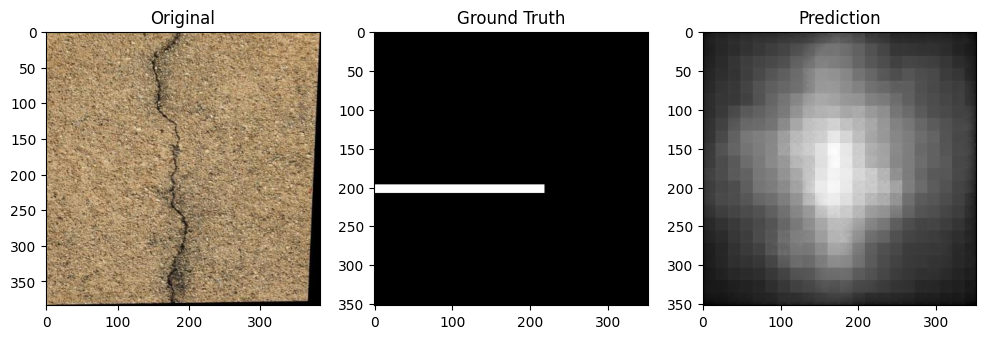

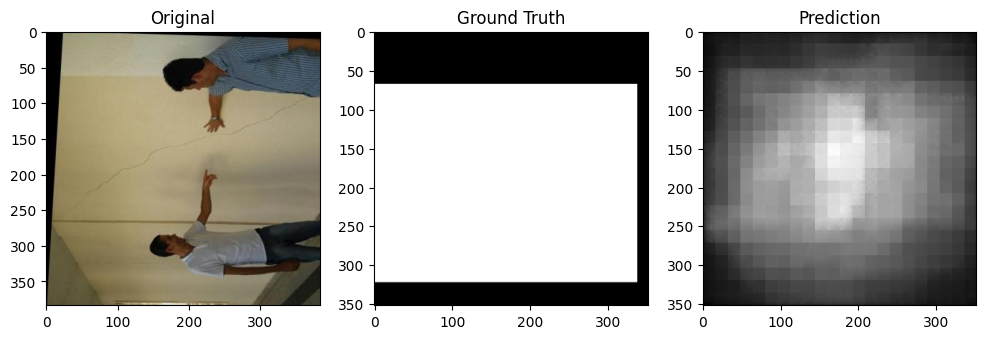

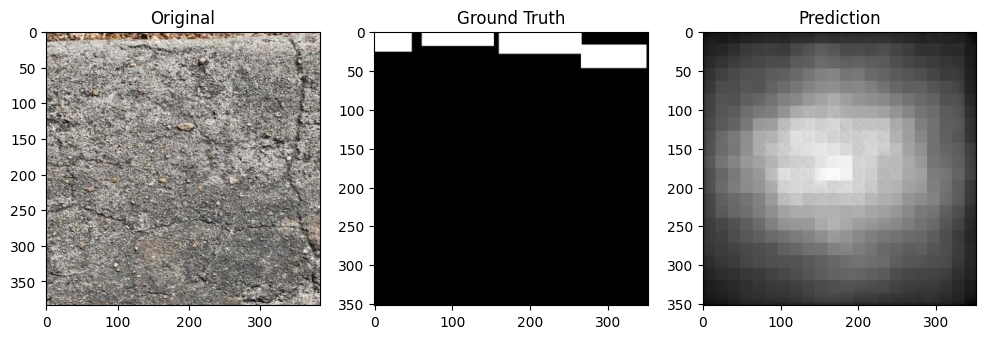

In [46]:
for i in range(3):

    img = cv2.imread(crack_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = cv2.imread(crack_masks[i],0)
    gt = cv2.resize(gt,(352,352))

    pred = predict(img,"segment crack")

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img)

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(gt,cmap="gray")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred,cmap="gray")

    plt.show()

In [47]:
os.makedirs("/kaggle/working/predictions",exist_ok=True)

In [48]:
for i,img_path in enumerate(crack_images):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred = predict(img,"segment crack")

    mask = (pred > 0.5) * 255

    filename = f"{i}__segment_crack.png"

    cv2.imwrite(
        f"/kaggle/working/predictions/{filename}",
        mask.astype(np.uint8)
    )

In [49]:
import time

img = cv2.imread(crack_images[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

start = time.time()

predict(img,"segment crack")

end = time.time()

print("Inference time per image:",end-start,"seconds")

Inference time per image: 0.048853158950805664 seconds


In [50]:
torch.save(model.state_dict(),"clipseg_model.pth")

import os
print("Model size:",os.path.getsize("clipseg_model.pth")/1e6,"MB")

Model size: 603.174939 MB


In [51]:
!zip -r predictions.zip /kaggle/working/predictions

  adding: kaggle/working/predictions/ (stored 0%)
  adding: kaggle/working/predictions/5124__segment_crack.png (deflated 45%)
  adding: kaggle/working/predictions/2382__segment_crack.png (deflated 84%)
  adding: kaggle/working/predictions/863__segment_crack.png (deflated 60%)
  adding: kaggle/working/predictions/4902__segment_crack.png (deflated 69%)
  adding: kaggle/working/predictions/260__segment_crack.png (deflated 43%)
  adding: kaggle/working/predictions/2072__segment_crack.png (deflated 42%)
  adding: kaggle/working/predictions/4967__segment_crack.png (deflated 73%)
  adding: kaggle/working/predictions/1206__segment_crack.png (deflated 42%)
  adding: kaggle/working/predictions/1597__segment_crack.png (deflated 87%)
  adding: kaggle/working/predictions/200__segment_crack.png (deflated 87%)
  adding: kaggle/working/predictions/4471__segment_crack.png (deflated 50%)
  adding: kaggle/working/predictions/3459__segment_crack.png (deflated 82%)
  adding: kaggle/working/predictions/881_